In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plot-Stil
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

# Daten laden
df = pd.read_csv("lmu_muenchen_2005_2025_clean.csv",
                 index_col="Datum",
                 parse_dates=True)

print(df.shape)
df.head()

(7670, 7)


,T_max,T_min,Regen,p_max,p_min,Sonne,ist_interpoliert
Datum,,,,,,,
2005-01-01,7.3,3.2,0.0,966.1,961.0,1.4,0
2005-01-02,8.0,1.2,1.0,967.8,957.6,0.0,0
2005-01-03,4.0,1.4,0.1,972.6,967.8,0.0,0
2005-01-04,6.8,3.3,0.0,971.1,967.3,4.3,0
2005-01-05,8.0,2.7,0.0,969.0,964.1,2.2,0


Train: 2005-01-01 → 2022-12-31  (6574 Tage)
Test:  2023-01-01 → 2024-12-31   (731 Tage)
Live:  2025-01-01 → 2025-12-31   (365 Tage)


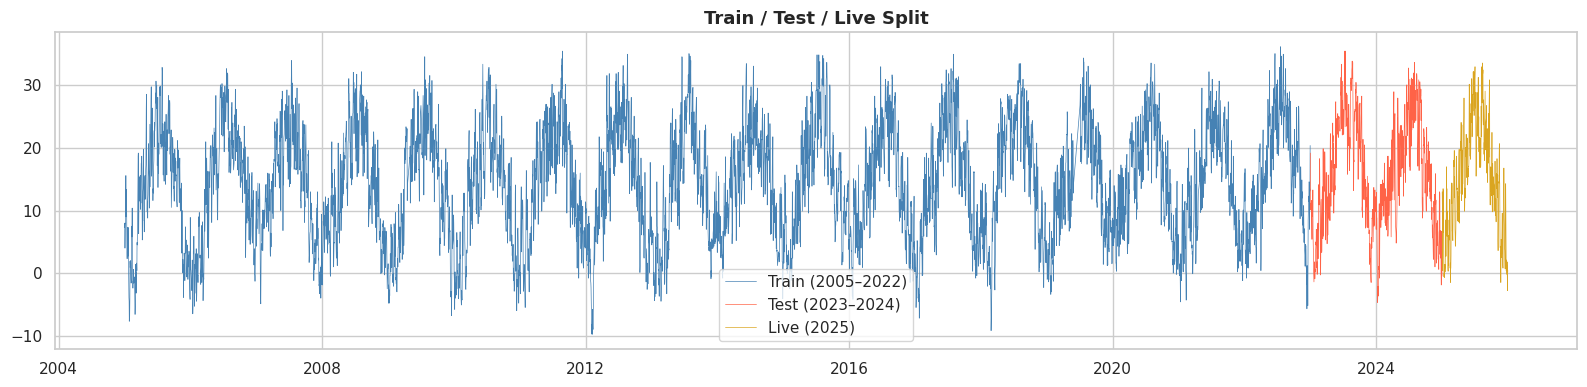

In [2]:
# Train/Test-Split — zeitlich sauber
# Train: 2005–2022  |  Test: 2023–2024  |  Live: 2025
train = df[df.index.year <= 2022]["T_max"]
test  = df[df.index.year.isin([2023, 2024])]["T_max"]
live  = df[df.index.year == 2025]["T_max"]

print(f"Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} Tage)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()}   ({len(test)} Tage)")
print(f"Live:  {live.index.min().date()} → {live.index.max().date()}   ({len(live)} Tage)")

# Visualisierung des Splits
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train.index, train, color="steelblue",  linewidth=0.5, label="Train (2005–2022)")
ax.plot(test.index,  test,  color="tomato",     linewidth=0.5, label="Test (2023–2024)")
ax.plot(live.index,  live,  color="goldenrod",  linewidth=0.5, label="Live (2025)")
ax.set_title("Train / Test / Live Split", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

Baseline MAE:  2.91 °C
Baseline RMSE: 3.71 °C


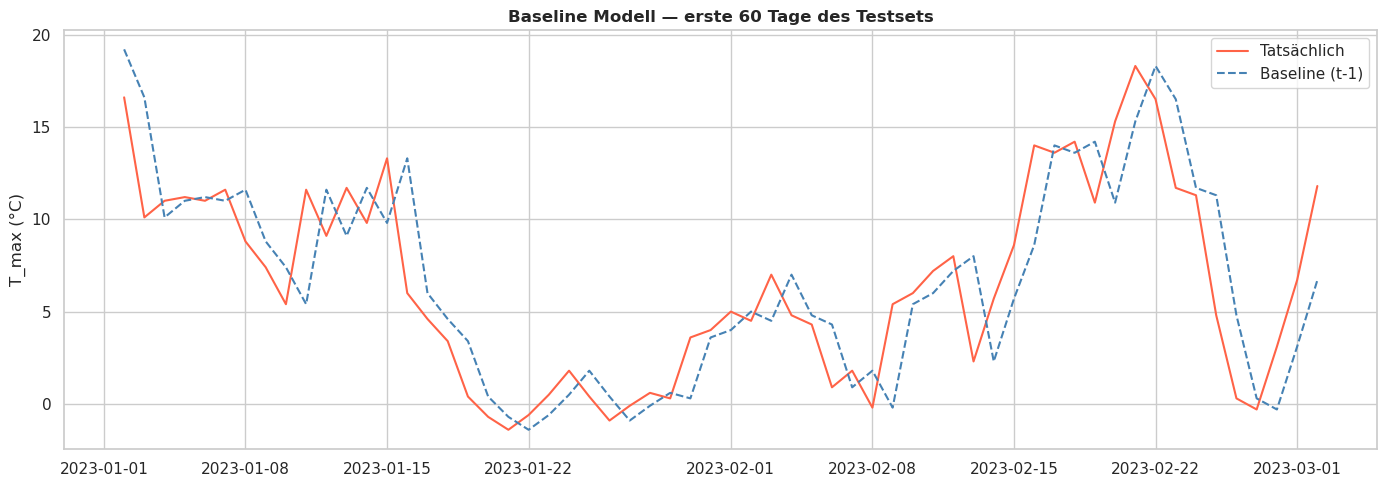

In [3]:
# ── Modell 1: Baseline (Persistence) ────────────────────────────
# Vorhersage: morgen = heute
baseline_pred = test.shift(1).dropna()
baseline_true = test.loc[baseline_pred.index]

mae_baseline  = mean_absolute_error(baseline_true, baseline_pred)
rmse_baseline = mean_squared_error(baseline_true, baseline_pred) ** 0.5

print(f"Baseline MAE:  {mae_baseline:.2f} °C")
print(f"Baseline RMSE: {rmse_baseline:.2f} °C")

# Visualisierung — ersten 60 Tage zoom
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(baseline_true.index[:60], baseline_true.iloc[:60],
        color="tomato", linewidth=1.5, label="Tatsächlich")
ax.plot(baseline_pred.index[:60], baseline_pred.iloc[:60],
        color="steelblue", linewidth=1.5, linestyle="--", label="Baseline (t-1)")
ax.set_title("Baseline Modell — erste 60 Tage des Testsets", fontweight="bold")
ax.set_ylabel("T_max (°C)")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
from xgboost import XGBRegressor

# ── Feature Engineering ──────────────────────────────────────────
def make_features(series):
    df_f = pd.DataFrame({"y": series})
    df_f["lag_1"]   = df_f["y"].shift(1)    # gestern
    df_f["lag_2"]   = df_f["y"].shift(2)    # vorgestern
    df_f["lag_7"]   = df_f["y"].shift(7)    # letzte Woche
    df_f["lag_365"] = df_f["y"].shift(365)  # Vorjahr
    df_f["roll_7"]  = df_f["y"].shift(1).rolling(7).mean()   # 7-Tage-Mittel
    df_f["roll_30"] = df_f["y"].shift(1).rolling(30).mean()  # 30-Tage-Mittel
    df_f["monat"]   = df_f.index.month
    df_f["tag_des_jahres"] = df_f.index.dayofyear
    return df_f.dropna()

features = make_features(df["T_max"])
feature_cols = ["lag_1", "lag_2", "lag_7", "lag_365",
                "roll_7", "roll_30", "monat", "tag_des_jahres"]

X_train = features.loc[features.index.year <= 2022, feature_cols]
y_train = features.loc[features.index.year <= 2022, "y"]
X_test  = features.loc[features.index.year.isin([2023, 2024]), feature_cols]
y_test  = features.loc[features.index.year.isin([2023, 2024]), "y"]

# ── Training ─────────────────────────────────────────────────────
model = XGBRegressor(n_estimators=500, learning_rate=0.05,
                     max_depth=4, random_state=42)
model.fit(X_train, y_train)

# ── Evaluation ───────────────────────────────────────────────────
xgb_pred = model.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = mean_squared_error(y_test, xgb_pred) ** 0.5

print(f"XGBoost MAE:  {mae_xgb:.2f} °C")
print(f"XGBoost RMSE: {rmse_xgb:.2f} °C")
print(f"\nVerbesserung vs. Baseline: {((mae_baseline - mae_xgb) / mae_baseline * 100):.1f}%")

XGBoost MAE:  2.84 °C
XGBoost RMSE: 3.49 °C

Verbesserung vs. Baseline: 2.4%


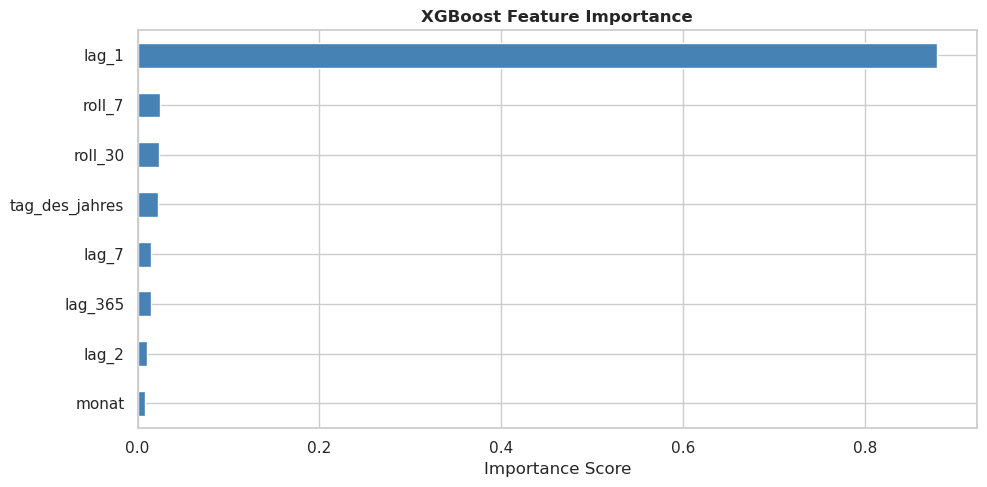

In [5]:
# Feature Importance
fig, ax = plt.subplots(figsize=(10, 5))
importance = pd.Series(model.feature_importances_, index=feature_cols)
importance.sort_values().plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("XGBoost Feature Importance", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [6]:
def make_features_v2(series):
    df_f = pd.DataFrame({"y": series})
    # Zyklische Kodierung des Jahrestags (sin/cos statt rohe Zahl)
    doy = df_f.index.dayofyear
    df_f["sin_doy"] = np.sin(2 * np.pi * doy / 365)
    df_f["cos_doy"] = np.cos(2 * np.pi * doy / 365)
    # Lags ohne lag_1
    df_f["lag_2"]   = df_f["y"].shift(2)
    df_f["lag_3"]   = df_f["y"].shift(3)
    df_f["lag_7"]   = df_f["y"].shift(7)
    df_f["lag_14"]  = df_f["y"].shift(14)
    df_f["lag_365"] = df_f["y"].shift(365)
    df_f["roll_7"]  = df_f["y"].shift(2).rolling(7).mean()
    df_f["roll_30"] = df_f["y"].shift(2).rolling(30).mean()
    df_f["monat"]   = df_f.index.month
    return df_f.dropna()

features_v2 = make_features_v2(df["T_max"])
feature_cols_v2 = ["sin_doy", "cos_doy", "lag_2", "lag_3",
                   "lag_7", "lag_14", "lag_365",
                   "roll_7", "roll_30", "monat"]

X_train_v2 = features_v2.loc[features_v2.index.year <= 2022, feature_cols_v2]
y_train_v2 = features_v2.loc[features_v2.index.year <= 2022, "y"]
X_test_v2  = features_v2.loc[features_v2.index.year.isin([2023, 2024]), feature_cols_v2]
y_test_v2  = features_v2.loc[features_v2.index.year.isin([2023, 2024]), "y"]

model_v2 = XGBRegressor(n_estimators=500, learning_rate=0.05,
                        max_depth=4, random_state=42)
model_v2.fit(X_train_v2, y_train_v2)

xgb_pred_v2 = model_v2.predict(X_test_v2)
mae_v2  = mean_absolute_error(y_test_v2, xgb_pred_v2)
rmse_v2 = mean_squared_error(y_test_v2, xgb_pred_v2) ** 0.5

print(f"XGBoost v2 MAE:  {mae_v2:.2f} °C")
print(f"XGBoost v2 RMSE: {rmse_v2:.2f} °C")
print(f"Verbesserung vs. Baseline: {((mae_baseline - mae_v2) / mae_baseline * 100):.1f}%")

XGBoost v2 MAE:  3.65 °C
XGBoost v2 RMSE: 4.52 °C
Verbesserung vs. Baseline: -25.6%


XGBoost v3 MAE:  2.81 °C
XGBoost v3 RMSE: 3.43 °C
Verbesserung vs. Baseline: 3.4%


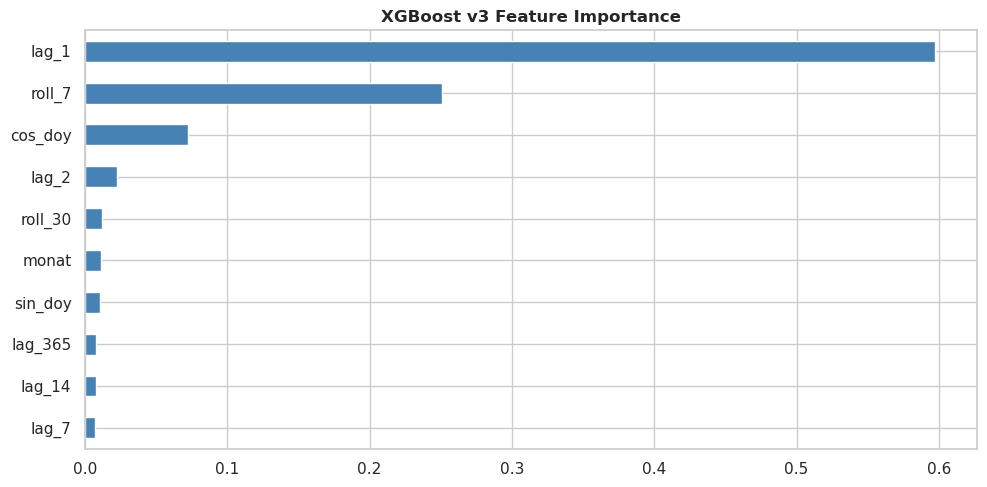

In [7]:
# ── Modell v3: lag_1 zurück, aber Modell stärker regularisieren ──
def make_features_v3(series):
    df_f = pd.DataFrame({"y": series})
    doy = df_f.index.dayofyear
    df_f["sin_doy"] = np.sin(2 * np.pi * doy / 365)
    df_f["cos_doy"] = np.cos(2 * np.pi * doy / 365)
    df_f["lag_1"]   = df_f["y"].shift(1)
    df_f["lag_2"]   = df_f["y"].shift(2)
    df_f["lag_7"]   = df_f["y"].shift(7)
    df_f["lag_14"]  = df_f["y"].shift(14)
    df_f["lag_365"] = df_f["y"].shift(365)
    df_f["roll_7"]  = df_f["y"].shift(1).rolling(7).mean()
    df_f["roll_30"] = df_f["y"].shift(1).rolling(30).mean()
    df_f["monat"]   = df_f.index.month
    return df_f.dropna()

features_v3  = make_features_v3(df["T_max"])
feature_cols_v3 = ["sin_doy", "cos_doy", "lag_1", "lag_2",
                   "lag_7", "lag_14", "lag_365",
                   "roll_7", "roll_30", "monat"]

X_train_v3 = features_v3.loc[features_v3.index.year <= 2022, feature_cols_v3]
y_train_v3 = features_v3.loc[features_v3.index.year <= 2022, "y"]
X_test_v3  = features_v3.loc[features_v3.index.year.isin([2023, 2024]), feature_cols_v3]
y_test_v3  = features_v3.loc[features_v3.index.year.isin([2023, 2024]), "y"]

model_v3 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,      # langsamer lernen
    max_depth=3,             # flachere Bäume → weniger Overfitting
    subsample=0.8,           # nur 80% der Daten pro Baum
    colsample_bytree=0.8,    # nur 80% der Features pro Baum
    random_state=42
)
model_v3.fit(X_train_v3, y_train_v3,
             eval_set=[(X_test_v3, y_test_v3)],
             verbose=False)

xgb_pred_v3 = model_v3.predict(X_test_v3)
mae_v3  = mean_absolute_error(y_test_v3, xgb_pred_v3)
rmse_v3 = mean_squared_error(y_test_v3, xgb_pred_v3) ** 0.5

print(f"XGBoost v3 MAE:  {mae_v3:.2f} °C")
print(f"XGBoost v3 RMSE: {rmse_v3:.2f} °C")
print(f"Verbesserung vs. Baseline: {((mae_baseline - mae_v3) / mae_baseline * 100):.1f}%")

# Feature Importance v3
fig, ax = plt.subplots(figsize=(10, 5))
importance_v3 = pd.Series(model_v3.feature_importances_, index=feature_cols_v3)
importance_v3.sort_values().plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("XGBoost v3 Feature Importance", fontweight="bold")
plt.tight_layout()
plt.show()

    Modell      MAE     RMSE  Verbesserung vs. Baseline (%)
  Baseline 2.905205 3.714393                            0.0
XGBoost v1 2.835498 3.492254                            2.4
XGBoost v2 3.648539 4.518292                          -25.6
XGBoost v3 2.806481 3.426369                            3.4


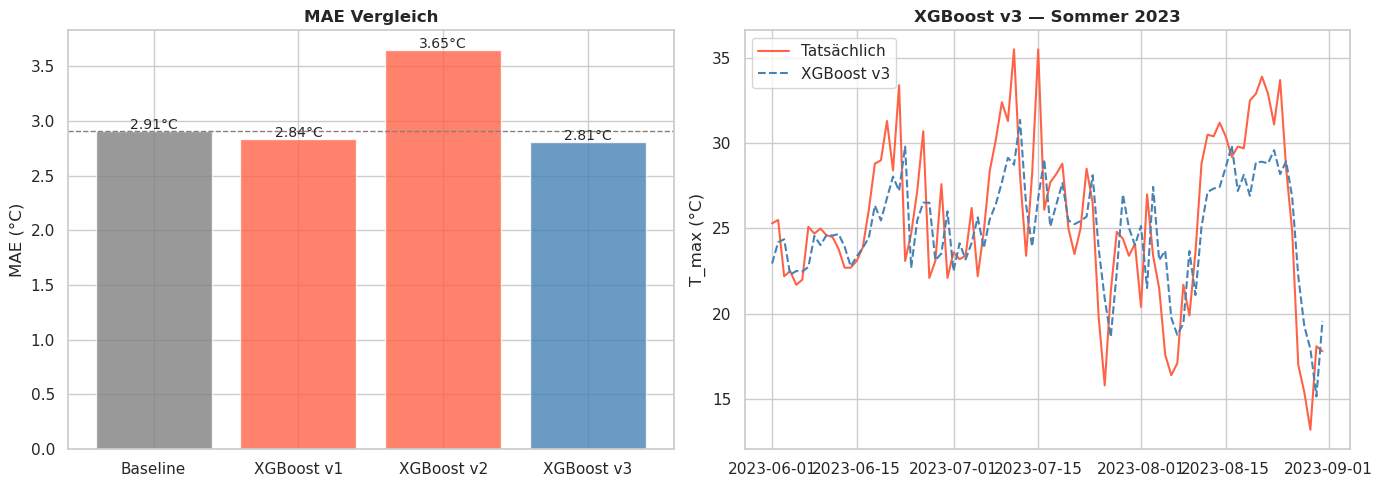

In [8]:
# ── Finaler Modellvergleich ──────────────────────────────────────
# Ergebnisse zusammenfassen
ergebnisse = pd.DataFrame({
    "Modell": ["Baseline", "XGBoost v1", "XGBoost v2", "XGBoost v3"],
    "MAE":  [mae_baseline, mae_xgb, mae_v2, mae_v3],
    "RMSE": [rmse_baseline, rmse_xgb, rmse_v2, rmse_v3],
})
ergebnisse["Verbesserung vs. Baseline (%)"] = (
    (mae_baseline - ergebnisse["MAE"]) / mae_baseline * 100
).round(1)
print(ergebnisse.to_string(index=False))

# ── Plot 1: MAE Vergleich ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

farben = ["gray", "tomato", "tomato", "steelblue"]
axes[0].bar(ergebnisse["Modell"], ergebnisse["MAE"],
            color=farben, alpha=0.8, edgecolor="white")
axes[0].axhline(mae_baseline, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("MAE Vergleich", fontweight="bold")
axes[0].set_ylabel("MAE (°C)")
for i, v in enumerate(ergebnisse["MAE"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}°C", ha="center", fontsize=10)

# ── Plot 2: Vorhersage vs. Realität (beste Modell) ───────────────
zoom = slice("2023-06-01", "2023-08-31")  # Sommer 2023
axes[1].plot(y_test_v3.loc[zoom].index,
             y_test_v3.loc[zoom],
             color="tomato", linewidth=1.5, label="Tatsächlich")
axes[1].plot(y_test_v3.loc[zoom].index,
             xgb_pred_v3[y_test_v3.index.isin(y_test_v3.loc[zoom].index)],
             color="steelblue", linewidth=1.5,
             linestyle="--", label="XGBoost v3")
axes[1].set_title("XGBoost v3 — Sommer 2023", fontweight="bold")
axes[1].set_ylabel("T_max (°C)")
axes[1].legend()

plt.tight_layout()
plt.show()

Folgende drei Schlussfolgerungen ergeben sich aus dem Modellvergleich:
    - lag_1 ist bei allen drei Modellen der dominante Prädiktor
    - Die Modelle haben Schwierigkeiten Extremwetter, wie Hitzetage vorherzusagen. Da diese in den Trainigsdaten zu selten vorkommen.
    - Das Modell v3 schlägt die Baseline um 3.4 %, real aber bescheiden, was zeigt dass die starke Autokorrelation der Zeitreihe einfache Modelle schwer zu übertreffen macht.